# DyslexiaLens — Multi-Modal, Multi-Task CNN Pipeline
## EMNIST-GAMBO Combined Dataset · Late Fusion · Dual-Head Architecture
---
**Architecture:** Keras Functional API · Custom ACN Layer · Late Fusion
**Inputs:** Image tensor (128×128×1) + 6 engineered clinical features
**Outputs:** Classification head (sigmoid) + Severity score head (MaskedHuber)
**Dataset:** EMNIST-GAMBO Balanced (~204k samples) — 1:1 class ratio

**Custom components (rubric requirements):**
- `AdaptiveContrastNorm` — custom `keras.layers.Layer` (§7)
- `MaskedHuberLoss` — custom `keras.losses.Loss`, severity head only (§7b)
- `MAEThresholdStopping` — custom `keras.callbacks.Callback` (§9b)
- `TensorBoard` callback → logs to `/kaggle/working/logs/` (§9b)
- Full `tf.GradientTape` custom training loop (§17)


## 1. Imports & Environment Setup

In [16]:
import os, re, zipfile, pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.losses import Huber
import tensorflow.keras.backend as K

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow  : {tf.__version__}")
print(f"Keras       : {keras.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")


TensorFlow  : 2.19.0
Keras       : 3.10.0
NumPy       : 2.0.2
Pandas      : 2.3.3
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Global Configuration

In [17]:
# ── Kaggle Paths (exact pattern from reference notebook) ─────────────────────
#
# Dataset slug  : adhyatmaaaa/gambo-emnist
# Mount root    : /kaggle/input/datasets/adhyatmaaaa/gambo-emnist/
#
# On-disk layout (confirmed from directory listing):
#
#   KAGGLE_INPUT/
#   ├── Dataset_Gambo_EMNIST (1)/          ← EMNIST-augmented, balanced 1:1
#   │     ├── Train/   {Corrected, Normal, Reversal}
#   │     ├── Validation/                  ← Validation folder EXISTS on disk here
#   │     └── Test/    {Corrected, Normal, Reversal}
#   ├── Dataset_Gambo_NoAugmentation/      ← reference / ablation only
#   │     ├── Train/   {Corrected, Normal, Reversal}
#   │     ├── Validation/ {Corrected, Normal, Reversal}
#   │     └── Test/    {Corrected, Normal, Reversal}
#   ├── Dataset_Dyslexia_EMNIST_FeatureEngineeringV2.csv
#   └── Dataset_Dyslexia_NoAugmentation_FeatureEngineeringV2.csv
#
# CRITICAL NOTE (from reference notebook cell 3):
#   The EMNIST dataset DOES have a physical Validation/ folder on disk.
#   No split remapping needed — Train→Train, Validation→Validation, Test→Test.

import os, re, pathlib, datetime
import numpy as np

KAGGLE_INPUT = "/kaggle/input/datasets/adhyatmaaaa/gambo-emnist"
IMG_ROOT     = f"{KAGGLE_INPUT}/Dataset_Gambo_EMNIST (1)"

CSV_EMNIST   = f"{KAGGLE_INPUT}/Dataset_Dyslexia_EMNIST_FeatureEngineeringV2.csv"
CSV_NOAUG    = f"{KAGGLE_INPUT}/Dataset_Dyslexia_NoAugmentation_FeatureEngineeringV2.csv"

WORKING_DIR      = "/kaggle/working"
CHECKPOINT_PATH  = f"{WORKING_DIR}/checkpoints/dyslexialens_best.weights.h5"
MODEL_SAVE_PATH  = f"{WORKING_DIR}/dyslexialens_model.keras"
SCALER_SAVE_PATH = f"{WORKING_DIR}/feature_scaler.pkl"
LOG_DIR          = f"{WORKING_DIR}/logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

os.makedirs(f"{WORKING_DIR}/checkpoints", exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# ── Image config ──────────────────────────────────────────────────────────────
IMG_SIZE        = (128, 128)          # downsampled from 224×224 source
IMG_CHANNELS    = 1
INPUT_SHAPE_IMG = (*IMG_SIZE, IMG_CHANNELS)

# ── Feature config ────────────────────────────────────────────────────────────
FEATURE_COLS = [
    "stroke_density",         # DS team v2 nomenclature (replaces 'ink_density')
    "center_of_mass_x",
    "center_of_mass_y",
    "bounding_box_ratio",
    "stroke_transitions",
    "horizontal_symmetry",
]
N_FEATURES = len(FEATURE_COLS)   # 6

# ── Severity proxy weights ────────────────────────────────────────────────────
SEV_W_SYMMETRY    = 0.55   # horizontal_symmetry → reversal effects (primary)
SEV_W_TRANSITIONS = 0.30   # stroke_transitions  → motor tremors (secondary)
SEV_W_BBOX        = 0.15   # bounding_box_ratio  → spatial compression (tertiary)

# ── Training hyperparameters ──────────────────────────────────────────────────
BATCH_SIZE     = 64
EPOCHS         = 50
LEARNING_RATE  = 1e-3
DROPOUT_RATE   = 0.40
SEED           = 42

# ── Loss weights (multi-task) ─────────────────────────────────────────────────
LOSS_WEIGHT_CLS = 1.0    # classification head dominates
LOSS_WEIGHT_SEV = 0.5    # severity head fine-tuned after clf stability

# ── Threshold sweep ───────────────────────────────────────────────────────────
THRESHOLD_SWEEP_RANGE = np.arange(0.30, 0.71, 0.01)
DEFAULT_THRESHOLD     = 0.40    # proven operational boundary from ablation study

# ── BinaryFocalLoss guard (BLACKLISTED) ───────────────────────────────────────
USE_FOCAL_LOSS = False
assert not USE_FOCAL_LOSS, "BinaryFocalLoss is blacklisted for DyslexiaLens."

# ── Hard path assertions ──────────────────────────────────────────────────────
assert os.path.isdir(IMG_ROOT),    f"IMG_ROOT not found: {IMG_ROOT}"
assert os.path.isfile(CSV_EMNIST), f"CSV not found: {CSV_EMNIST}"

print("Configuration loaded.")
print(f"  KAGGLE_INPUT      : {KAGGLE_INPUT}")
print(f"  IMG_ROOT          : {IMG_ROOT}")
print(f"  CSV_EMNIST        : {CSV_EMNIST}")
print(f"  Image input shape : {INPUT_SHAPE_IMG}")
print(f"  Feature vector dim: {N_FEATURES}  →  {FEATURE_COLS}")
print(f"  Loss weights      : clf={LOSS_WEIGHT_CLS}, sev={LOSS_WEIGHT_SEV}")
print(f"  Operational thresh: {DEFAULT_THRESHOLD}")


Configuration loaded.
  KAGGLE_INPUT      : /kaggle/input/datasets/adhyatmaaaa/gambo-emnist
  IMG_ROOT          : /kaggle/input/datasets/adhyatmaaaa/gambo-emnist/Dataset_Gambo_EMNIST (1)
  CSV_EMNIST        : /kaggle/input/datasets/adhyatmaaaa/gambo-emnist/Dataset_Dyslexia_EMNIST_FeatureEngineeringV2.csv
  Image input shape : (128, 128, 1)
  Feature vector dim: 6  →  ['stroke_density', 'center_of_mass_x', 'center_of_mass_y', 'bounding_box_ratio', 'stroke_transitions', 'horizontal_symmetry']
  Loss weights      : clf=1.0, sev=0.5
  Operational thresh: 0.4


## 3. Dataset Inventory

In [18]:
# Verify the on-disk structure matches the expected layout.
# No extraction needed — dataset is already mounted by Kaggle.

print(f"Verifying dataset structure under: {IMG_ROOT}\n")

total = 0
for split in ["Train", "Validation", "Test"]:
    for cat in ["Corrected", "Normal", "Reversal"]:
        folder = pathlib.Path(IMG_ROOT) / split / cat
        if folder.exists():
            count = len(list(folder.glob("*.png")))
            total += count
            print(f"  {split:12s} / {cat:10s} : {count:,} images")
        else:
            print(f"  [MISSING] {split}/{cat}")

print(f"\nTotal .png files verified: {total:,}")
print(f"Expected ~204,833 for EMNIST-balanced dataset.")


Verifying dataset structure under: /kaggle/input/datasets/adhyatmaaaa/gambo-emnist/Dataset_Gambo_EMNIST (1)

  Train        / Corrected  : 49,553 images
  Train        / Normal     : 71,707 images
  Train        / Reversal   : 22,123 images
  Validation   / Corrected  : 10,619 images
  Validation   / Normal     : 15,366 images
  Validation   / Reversal   : 4,740 images
  Test         / Corrected  : 10,619 images
  Test         / Normal     : 15,366 images
  Test         / Reversal   : 4,740 images

Total .png files verified: 204,833
Expected ~204,833 for EMNIST-balanced dataset.


## 4. Feature CSV Loading & Severity Proxy Construction

In [19]:
# ── 4.1  Load primary CSV (EMNIST-balanced) ──────────────────────────────────
df_raw = pd.read_csv(CSV_EMNIST)
print(f"Raw CSV shape    : {df_raw.shape}")
print(f"Class balance    : {df_raw['target_class'].value_counts().to_dict()}")
print(f"Splits           : {df_raw['split'].value_counts().to_dict()}")
print(f"NaN check        : {df_raw.isnull().sum().sum()} total NaNs")


Raw CSV shape    : (204833, 12)
Class balance    : {0: 102439, 1: 102394}
Splits           : {'Train': 143383, 'Test': 30725, 'Validation': 30725}
NaN check        : 0 total NaNs


In [20]:
# ── 4.2  Build absolute local paths from CSV's Windows-style image_path ────────
#
# CSV stores: 'Dataset\\Gambo_EMNIST_Balanced\\Test\\Corrected\\file.png'
# On disk   : {IMG_ROOT}/Test/Corrected/file.png
#
# The EMNIST (1) dataset has physical Train/, Validation/, and Test/ folders,
# so we map the last 3 path components (split/category/filename) directly
# onto IMG_ROOT with no remapping required.

def build_image_path(row, img_root: str) -> str:
    # Split Windows/Unix path and grab last 3 parts: split/category/filename
    parts = re.split(r'[\\/]+', row['image_path'].strip())
    return os.path.join(img_root, *parts[-3:])

df_raw['local_path'] = df_raw.apply(
    lambda row: build_image_path(row, IMG_ROOT), axis=1
)

# Spot-check: verify first 5 paths resolve to actual files
print("Path resolution spot-check:")
n_missing = 0
for p in df_raw['local_path'].head(5):
    exists = os.path.exists(p)
    if not exists:
        n_missing += 1
    print(f"  {'✓' if exists else '✗'}  {p}")

total_missing = df_raw['local_path'].apply(lambda p: not os.path.exists(p)).sum()
print(f"\nTotal missing paths in full dataset: {total_missing:,}")
if total_missing == 0:
    print("✓ All paths resolve correctly.")
else:
    print(f"⚠ {total_missing:,} paths are missing — check IMG_ROOT in §2.")


Path resolution spot-check:
  ✓  /kaggle/input/datasets/adhyatmaaaa/gambo-emnist/Dataset_Gambo_EMNIST (1)/Test/Corrected/Test_Corrected_1_00017.png
  ✓  /kaggle/input/datasets/adhyatmaaaa/gambo-emnist/Dataset_Gambo_EMNIST (1)/Test/Corrected/Test_Corrected_1_00027.png
  ✓  /kaggle/input/datasets/adhyatmaaaa/gambo-emnist/Dataset_Gambo_EMNIST (1)/Test/Corrected/Test_Corrected_1_00029.png
  ✓  /kaggle/input/datasets/adhyatmaaaa/gambo-emnist/Dataset_Gambo_EMNIST (1)/Test/Corrected/Test_Corrected_1_00036.png
  ✓  /kaggle/input/datasets/adhyatmaaaa/gambo-emnist/Dataset_Gambo_EMNIST (1)/Test/Corrected/Test_Corrected_1_00043.png

Total missing paths in full dataset: 0
✓ All paths resolve correctly.


In [21]:
# ── 4.3  Severity Proxy Construction ─────────────────────────────────────────
#
# Strategy (agreed specification):
#   Control group (target_class == 0)  → severity = 0.0  (no clinical indicators)
#   Dyslexia group (target_class == 1) → normalized weighted deviation index ∈ [0, 1]
#
# Proxy formula (dyslexia samples only):
#   raw_sev = w_sym  * (1 - horizontal_symmetry)    # asymmetry = reversal signal
#           + w_trans * norm(stroke_transitions)      # motor tremor indicator
#           + w_bbox  * norm(bounding_box_ratio)      # spatial compression
#
# Each sub-component is min-max normalised within the dyslexia sub-population
# before weighting so that each feature contributes on an equal [0,1] scale
# prior to weighting. The composite is then re-normalised to [0,1].

def build_severity_proxy(df: pd.DataFrame) -> pd.Series:
    sev = pd.Series(0.0, index=df.index, dtype=np.float32)

    mask = df['target_class'] == 1
    sub  = df.loc[mask].copy()

    def minmax(s: pd.Series) -> pd.Series:
        lo, hi = s.min(), s.max()
        return (s - lo) / (hi - lo + 1e-8)

    # Reversal component: lower symmetry → higher deviation
    asym  = minmax(1.0 - sub['horizontal_symmetry'])

    # Motor tremor component: more transitions → higher deviation
    trans = minmax(sub['stroke_transitions'])

    # Spatial compression: extreme bbox ratio → higher deviation
    bbox  = minmax(sub['bounding_box_ratio'])

    raw = (
        SEV_W_SYMMETRY    * asym  +
        SEV_W_TRANSITIONS * trans +
        SEV_W_BBOX        * bbox
    )

    # Final normalisation → [0, 1]
    sev.loc[mask] = minmax(raw).values.astype(np.float32)
    return sev


df_raw['severity_proxy'] = build_severity_proxy(df_raw)

print("Severity proxy statistics:")
print(f"  Control  (0) mean : {df_raw.loc[df_raw['target_class']==0,'severity_proxy'].mean():.4f}")
print(f"  Dyslexia (1) mean : {df_raw.loc[df_raw['target_class']==1,'severity_proxy'].mean():.4f}")
print(f"  Dyslexia (1) std  : {df_raw.loc[df_raw['target_class']==1,'severity_proxy'].std():.4f}")
print(f"  Dyslexia (1) range: "
      f"[{df_raw.loc[df_raw['target_class']==1,'severity_proxy'].min():.4f}, "
      f"{df_raw.loc[df_raw['target_class']==1,'severity_proxy'].max():.4f}]")


Severity proxy statistics:
  Control  (0) mean : 0.0000
  Dyslexia (1) mean : 0.4164
  Dyslexia (1) std  : 0.1077
  Dyslexia (1) range: [0.0000, 1.0000]


## 5. Feature Scaling & Dataset Splits

In [22]:
# ── 5.1  Stratified split using CSV 'split' column (pre-defined) ─────────────
df_train = df_raw[df_raw['split'] == 'Train'].reset_index(drop=True)
df_val   = df_raw[df_raw['split'] == 'Validation'].reset_index(drop=True)
df_test  = df_raw[df_raw['split'] == 'Test'].reset_index(drop=True)

print(f"Train      : {len(df_train):,}  "
      f"(class 0: {(df_train['target_class']==0).sum():,} | "
      f"class 1: {(df_train['target_class']==1).sum():,})")
print(f"Validation : {len(df_val):,}  "
      f"(class 0: {(df_val['target_class']==0).sum():,} | "
      f"class 1: {(df_val['target_class']==1).sum():,})")
print(f"Test       : {len(df_test):,}  "
      f"(class 0: {(df_test['target_class']==0).sum():,} | "
      f"class 1: {(df_test['target_class']==1).sum():,})")


Train      : 143,383  (class 0: 71,707 | class 1: 71,676)
Validation : 30,725  (class 0: 15,366 | class 1: 15,359)
Test       : 30,725  (class 0: 15,366 | class 1: 15,359)


In [23]:
# ── 5.2  MinMax-scale engineered features (fit ONLY on train) ────────────────
scaler = MinMaxScaler()
scaler.fit(df_train[FEATURE_COLS])

X_feat_train = scaler.transform(df_train[FEATURE_COLS]).astype(np.float32)
X_feat_val   = scaler.transform(df_val[FEATURE_COLS]).astype(np.float32)
X_feat_test  = scaler.transform(df_test[FEATURE_COLS]).astype(np.float32)

y_cls_train  = df_train['target_class'].values.astype(np.float32)
y_cls_val    = df_val['target_class'].values.astype(np.float32)
y_cls_test   = df_test['target_class'].values.astype(np.float32)

y_sev_train  = df_train['severity_proxy'].values.astype(np.float32)
y_sev_val    = df_val['severity_proxy'].values.astype(np.float32)
y_sev_test   = df_test['severity_proxy'].values.astype(np.float32)

print(f"Feature matrix shape — Train: {X_feat_train.shape} | Val: {X_feat_val.shape} | Test: {X_feat_test.shape}")
print(f"Scaler feature range: {scaler.data_min_.round(3)} → {scaler.data_max_.round(3)}")


Feature matrix shape — Train: (143383, 6) | Val: (30725, 6) | Test: (30725, 6)
Scaler feature range: [0.014 6.803 6.71  0.179 0.429 0.561] → [ 0.44  21.386 19.868  8.333  5.571  1.   ]


In [24]:
# ── 5.3  Sample weights for balanced training (multi-output compatible) ───────
#
# Keras `class_weight` is ONLY supported for single-output models.
# For multi-output models (like ours with classification_head + severity_head),
# the correct approach is to bake per-sample weights directly into the
# tf.data pipeline as a third element: (inputs, targets, sample_weight).
#
# We compute the same balanced weighting that class_weight='balanced' would
# produce, but as a per-sample float array instead of a class dict.

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_cls_train
)
CLASS_WEIGHTS = {0: float(class_weights_array[0]), 1: float(class_weights_array[1])}
print(f"Class weights: {CLASS_WEIGHTS}")
print(f"  Class 0 (Control)  weight: {CLASS_WEIGHTS[0]:.4f}")
print(f"  Class 1 (Dyslexia) weight: {CLASS_WEIGHTS[1]:.4f}")

# Build per-sample weight vectors for train split only
# Val/Test use uniform weights (no reweighting at eval time)
sample_weights_train = np.where(
    y_cls_train == 1,
    CLASS_WEIGHTS[1],
    CLASS_WEIGHTS[0]
).astype(np.float32)

print(f"\nSample weight vector shape : {sample_weights_train.shape}")
print(f"Mean sample weight (train) : {sample_weights_train.mean():.4f}  (should be ~1.0 for balanced)")


Class weights: {0: 0.9997838425816169, 1: 1.0002162509068586}
  Class 0 (Control)  weight: 0.9998
  Class 1 (Dyslexia) weight: 1.0002

Sample weight vector shape : (143383,)
Mean sample weight (train) : 1.0000  (should be ~1.0 for balanced)


## 6. tf.data Input Pipeline

In [25]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(path: str) -> tf.Tensor:
    """
    Load a PNG from disk, decode to grayscale, resize to 128×128,
    and normalise pixel values to [0, 1].
    Source images are stored at 224×224; downsampled at load time.
    """
    raw = tf.io.read_file(path)
    img = tf.image.decode_png(raw, channels=IMG_CHANNELS)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0
    return img


def augment_image(img: tf.Tensor) -> tf.Tensor:
    """
    Lightweight augmentation applied ONLY during training.
    Preserves stroke structure to avoid confounding clinical features.
    """
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.08)
    img = tf.image.random_contrast(img, lower=0.92, upper=1.08)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img


def make_dataset(
    paths, features, y_cls, y_sev,
    sample_weights=None,
    batch_size=BATCH_SIZE,
    training=False,
    shuffle_buffer=2048
) -> tf.data.Dataset:
    """
    Build a multi-input (image + feature vector), multi-output
    (classification + severity) tf.data.Dataset.

    For multi-output models, Keras does not support `class_weight` in model.fit().
    Class balancing is handled via `sample_weight` baked into the dataset as
    the third element of each (inputs, targets, sample_weight) tuple.
    Val/Test sets pass sample_weights=None → uniform weight of 1.0 per sample.
    """
    path_ds = tf.data.Dataset.from_tensor_slices(paths)
    feat_ds = tf.data.Dataset.from_tensor_slices(features)
    cls_ds  = tf.data.Dataset.from_tensor_slices(y_cls)
    sev_ds  = tf.data.Dataset.from_tensor_slices(y_sev)

    img_ds = path_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        img_ds = img_ds.map(augment_image, num_parallel_calls=AUTOTUNE)

    # Build sample weight tensor — uniform 1.0 for val/test
    if sample_weights is not None:
        sw_ds = tf.data.Dataset.from_tensor_slices(
            sample_weights.astype(np.float32)
        )
    else:
        sw_ds = tf.data.Dataset.from_tensor_slices(
            np.ones(len(y_cls), dtype=np.float32)
        )

    # Zip everything into (inputs_dict, targets_dict, sample_weight)
    ds = tf.data.Dataset.zip((
        tf.data.Dataset.zip((img_ds, feat_ds)),
        tf.data.Dataset.zip((cls_ds, sev_ds)),
        sw_ds
    ))

    ds = ds.map(
        lambda inputs, targets, sw: (
            {'image_input': inputs[0], 'feature_input': inputs[1]},
            {'classification_head': targets[0], 'severity_head': targets[1]},
            sw
        ),
        num_parallel_calls=AUTOTUNE
    )

    if training:
        ds = ds.shuffle(shuffle_buffer, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# Build all three datasets
train_ds = make_dataset(
    df_train['local_path'].values, X_feat_train, y_cls_train, y_sev_train,
    sample_weights=sample_weights_train,   # ← balanced class weights per sample
    training=True
)
val_ds = make_dataset(
    df_val['local_path'].values, X_feat_val, y_cls_val, y_sev_val,
    sample_weights=None,    # uniform — no reweighting at eval time
    training=False
)
test_ds = make_dataset(
    df_test['local_path'].values, X_feat_test, y_cls_test, y_sev_test,
    sample_weights=None,
    training=False
)

# Sanity check — inspect one batch: should now be a 3-tuple
for inputs, targets, sw in train_ds.take(1):
    print("Image input shape   :", inputs['image_input'].shape)
    print("Feature input shape :", inputs['feature_input'].shape)
    print("Classification y    :", targets['classification_head'].shape)
    print("Severity y          :", targets['severity_head'].shape)
    print("Sample weights      :", sw.shape, " sample:", sw[:4].numpy())


Image input shape   : (64, 128, 128, 1)
Feature input shape : (64, 6)
Classification y    : (64,)
Severity y          : (64,)
Sample weights      : (64,)  sample: [1.0002162 1.0002162 1.0002162 1.0002162]


## 7. Custom AdaptiveContrastNorm (ACN) Layer

In [26]:
class AdaptiveContrastNorm(layers.Layer):
    """
    AdaptiveContrastNorm (ACN) — proven custom layer from DyslexiaLens ablation study.
    
    Motivation:
        Handwriting images exhibit highly variable local contrast (ink bleed, paper
        texture, scanner differences). Standard BatchNorm operates on feature maps
        *after* convolution, but ACN acts *on the raw image space* before any
        learnable weights, providing contrast normalisation that is adaptive per
        sample and per spatial region.

    Mechanism:
        For each input sample, ACN computes:
            μ  = mean(x)          — per-sample spatial mean
            σ  = std(x) + ε       — per-sample spatial std (stabilised)
            x̂  = (x − μ) / σ     — zero-mean, unit-variance normalisation
            y  = γ * x̂ + β       — learnable affine re-scaling (2 params per channel)

        γ and β are initialised to 1 and 0 respectively (identity start),
        allowing the network to learn optimal contrast amplification per channel.

    Why NOT BatchNorm here:
        BN computes stats across the batch dimension, making it batch-size
        dependent and unstable at small batch sizes. ACN is fully instance-
        independent, critical for variable-size inference batches at deployment.

    Args:
        epsilon (float): Numerical stability term. Default: 1e-6.
    """

    def __init__(self, epsilon: float = 1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        # Learnable affine parameters: one gamma and one beta per channel
        channels = input_shape[-1]
        self.gamma = self.add_weight(
            name='gamma',
            shape=(1, 1, 1, channels),
            initializer='ones',
            trainable=True
        )
        self.beta = self.add_weight(
            name='beta',
            shape=(1, 1, 1, channels),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)

    def call(self, x: tf.Tensor, training=None) -> tf.Tensor:
        # Compute per-sample spatial statistics across H and W dimensions
        axes = [1, 2]   # height and width
        mu  = tf.reduce_mean(x, axis=axes, keepdims=True)
        sigma = tf.math.reduce_std(x, axis=axes, keepdims=True) + self.epsilon

        x_norm = (x - mu) / sigma
        return self.gamma * x_norm + self.beta

    def get_config(self):
        config = super().get_config()
        config.update({'epsilon': self.epsilon})
        return config


## 7b. Custom Loss Function — MaskedHuberLoss

In [27]:
class MaskedHuberLoss(keras.losses.Loss):
    """
    Custom loss function — satisfies rubric requirement for a custom Loss component.

    MaskedHuberLoss: Huber loss applied ONLY to dyslexia samples (severity_proxy > 0).

    Motivation (from run-1 analysis):
        Standard Huber loss penalises ALL samples equally. Because control samples
        have a severity target of exactly 0.0, but the network's natural output range
        doesn't anchor to 0.0 without explicit pressure, the head settles at a
        non-zero floor (~0.14 in run-1). This caused severity MAE = 0.424.

    Fix:
        mask = (y_true > 0.0)   →  1.0 for dyslexia, 0.0 for control
        Loss is computed per-sample, multiplied by mask, then normalised
        by the number of dyslexia samples in the batch (not total batch size).
        Control samples contribute ZERO gradient to the severity head,
        forcing it to learn the correct 0.0 floor naturally.

    Args:
        delta (float): Huber loss transition point. Default: 0.5.
                       Below delta → quadratic (like MSE).
                       Above delta → linear (like MAE, outlier-robust).
    """

    def __init__(self, delta: float = 0.5, **kwargs):
        super().__init__(**kwargs)
        self.delta = delta
        self._huber_fn = Huber(delta=delta, reduction='none')

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1, 1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1, 1]), tf.float32)

        # 1.0 where sample is dyslexia (target > 0.0), 0.0 for control
        mask = tf.cast(y_true > 0.0, tf.float32)

        # Per-sample Huber loss (reduction='none' → shape [batch])
        per_sample = self._huber_fn(y_true, y_pred)

        # Zero-out control samples
        masked = per_sample * tf.squeeze(mask, axis=-1)

        # Normalise by dyslexia count only (not full batch size)
        n_dyslexia = tf.reduce_sum(mask) + 1e-8
        return tf.reduce_sum(masked) / n_dyslexia

    def get_config(self):
        config = super().get_config()
        config.update({'delta': self.delta})
        return config


# Smoke-test: control samples must contribute 0 loss
_y_true_test = tf.constant([[0.0], [0.0], [0.6], [0.4]], dtype=tf.float32)
_y_pred_test = tf.constant([[0.3], [0.2], [0.5], [0.5]], dtype=tf.float32)
_loss_masked  = MaskedHuberLoss(delta=0.5)(_y_true_test, _y_pred_test)
_loss_std     = Huber(delta=0.5)(_y_true_test, _y_pred_test)
print(f"MaskedHuberLoss smoke-test:")
print(f"  Standard Huber (all 4 samples) : {_loss_std.numpy():.4f}")
print(f"  MaskedHuber   (dyslexia only)  : {_loss_masked.numpy():.4f}")
print(f"  Control samples excluded        : ✓ (masked loss < standard loss)")
print(f"  MaskedHuberLoss class ready.")


MaskedHuberLoss smoke-test:
  Standard Huber (all 4 samples) : 0.0188
  MaskedHuber   (dyslexia only)  : 0.0050
  Control samples excluded        : ✓ (masked loss < standard loss)
  MaskedHuberLoss class ready.


## 8. Model Architecture — Late Fusion + Dual-Head (Functional API)

In [28]:
def build_dyslexialens_model(
    img_shape=INPUT_SHAPE_IMG,
    n_features=N_FEATURES,
    dropout_rate=DROPOUT_RATE
) -> Model:
    """
    DyslexiaLens Multi-Modal, Multi-Task Model.

    Architecture Overview:
    ─────────────────────────────────────────────────────────────
    INPUT A (image_input)                  INPUT B (feature_input)
         │                                        │
    AdaptiveContrastNorm (ACN)           Dense(32, relu)
         │                                  BatchNorm
    Conv2D(32, 3×3, relu)                Dense(64, relu)
    BatchNorm → MaxPool → Dropout              │
         │                               feature_embedding
    Conv2D(64, 3×3, relu)
    BatchNorm → MaxPool → Dropout
         │
    Conv2D(128, 3×3, relu)
    BatchNorm → MaxPool → Dropout
         │
    Conv2D(256, 3×3, relu)
    BatchNorm → GlobalAvgPool
         │
    image_embedding
         │
         └──────── Concatenate ────────┘
                        │
                 Dense(256, relu)
                 BatchNorm + Dropout
                 Dense(128, relu)
                 Dropout
                        │
           ┌────────────┴────────────┐
           │                         │
    Dense(1, sigmoid)         Dense(1, sigmoid)
    classification_head       severity_head
    ─────────────────────────────────────────────────────────────
    """

    # ── Input A: Image Branch ─────────────────────────────────────────────────
    image_input = Input(shape=img_shape, name='image_input')

    # ACN: adaptive contrast normalisation (proven ablation winner)
    x = AdaptiveContrastNorm(name='acn')(image_input)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)
    x = layers.Dropout(dropout_rate * 0.5, name='drop1')(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)
    x = layers.Dropout(dropout_rate * 0.5, name='drop2')(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)
    x = layers.Dropout(dropout_rate * 0.5, name='drop3')(x)

    # Block 4 — deeper feature extraction, GlobalAvgPool to avoid spatial overfit
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu', name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    image_embedding = layers.GlobalAveragePooling2D(name='image_embedding')(x)

    # ── Input B: Clinical Feature Branch ─────────────────────────────────────
    feature_input = Input(shape=(n_features,), name='feature_input')

    f = layers.Dense(32, activation='relu', name='feat_dense1')(feature_input)
    f = layers.BatchNormalization(name='feat_bn1')(f)
    feature_embedding = layers.Dense(64, activation='relu', name='feature_embedding')(f)

    # ── Late Fusion: Concatenate both embeddings ──────────────────────────────
    fused = layers.Concatenate(name='late_fusion')([image_embedding, feature_embedding])

    # ── Shared Fusion Layers ──────────────────────────────────────────────────
    fused = layers.Dense(256, activation='relu', name='fusion_dense1')(fused)
    fused = layers.BatchNormalization(name='fusion_bn1')(fused)
    fused = layers.Dropout(dropout_rate, name='fusion_drop1')(fused)
    fused = layers.Dense(128, activation='relu', name='fusion_dense2')(fused)
    fused = layers.Dropout(dropout_rate * 0.5, name='fusion_drop2')(fused)

    # ── Head 1: Classification (Dyslexia vs. Control) ─────────────────────────
    # sigmoid → bounded [0,1]; threshold sweep at t=0.40 post-training
    classification_head = layers.Dense(
        1, activation='sigmoid', name='classification_head'
    )(fused)

    # ── Head 2: Severity Score (continuous deviation index) ───────────────────
    # sigmoid → naturally bounded [0,1]; proxy target also in [0,1]
    # Loss: Huber (MAE-aligned, outlier-robust per project rubric)
    severity_head = layers.Dense(
        1, activation='sigmoid', name='severity_head'
    )(fused)

    # ── Assemble Functional Model ─────────────────────────────────────────────
    model = Model(
        inputs=[image_input, feature_input],
        outputs=[classification_head, severity_head],
        name='DyslexiaLens_LateFusion'
    )

    return model


model = build_dyslexialens_model()
model.summary(line_length=100, expand_nested=True)


Model: "DyslexiaLens_LateFusion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)    │ (None, 128, 128, 1)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ acn (AdaptiveContrastNorm)  │ (None, 128, 128, 1)     │              2 │ image_input[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv1 (Conv2D)              │ (None, 128, 128, 32)    │            320 │ acn[0][0]               │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn1 (BatchNormalization)    │ (None, 128, 128, 32)    │            128 │ conv1[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ pool1 (MaxPooling2D)        │ (None, 64, 64, 32)      │              0 │ bn1[0][0]               │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ drop1 (Dropout)             │ (None, 64, 64, 32)      │              0 │ pool1[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2 (Conv2D)              │ (None, 64, 64, 64)      │         18,496 │ drop1[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn2 (BatchNormalization)    │ (None, 64, 64, 64)      │            256 │ conv2[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ pool2 (MaxPooling2D)        │ (None, 32, 32, 64)      │              0 │ bn2[0][0]               │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ drop2 (Dropout)             │ (None, 32, 32, 64)      │              0 │ pool2[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv3 (Conv2D)              │ (None, 32, 32, 128)     │         73,856 │ drop2[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn3 (BatchNormalization)    │ (None, 32, 32, 128)     │            512 │ conv3[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ pool3 (MaxPooling2D)        │ (None, 16, 16, 128)     │              0 │ bn3[0][0]               │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ drop3 (Dropout)             │ (None, 16, 16, 128)     │              0 │ pool3[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ feature_input (InputLayer)  │ (None, 6)               │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv4 (Conv2D)              │ (None, 16, 16, 256)     │        295,168 │ drop3[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ feat_dense1 (Dense)         │ (None, 32)              │            224 │ feature_input[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn4 (BatchNormalization)    │ (None, 16, 16, 256)     │          1,024 │ conv4[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ feat_bn1                    │ (None, 32)              │    

 Total params: 508,580 (1.94 MB)

 Trainable params: 507,044 (1.93 MB)

 Non-trainable params: 1,536 (6.00 KB)

## 9. Model Compilation

In [29]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={
        'classification_head': keras.losses.BinaryCrossentropy(),
        'severity_head':       MaskedHuberLoss(delta=0.5),   # custom loss (rubric req.)
    },
    loss_weights={
        'classification_head': LOSS_WEIGHT_CLS,
        'severity_head':       LOSS_WEIGHT_SEV,
    },
    metrics={
        'classification_head': [
            keras.metrics.BinaryAccuracy(name='accuracy'),
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ],
        'severity_head': [
            keras.metrics.MeanAbsoluteError(name='mae'),
            keras.metrics.RootMeanSquaredError(name='rmse'),
        ],
    }
)
print("Model compiled successfully.")
print(f"  Optimiser     : Adam (lr={LEARNING_RATE})")
print(f"  Clf loss      : BinaryCrossentropy      (weight={LOSS_WEIGHT_CLS})")
print(f"  Severity loss : MaskedHuberLoss(δ=0.5)  (weight={LOSS_WEIGHT_SEV})  ← custom loss")
print(f"  [GUARD] BinaryFocalLoss: DISABLED — gradient destabilisation documented")


Model compiled successfully.
  Optimiser     : Adam (lr=0.001)
  Clf loss      : BinaryCrossentropy      (weight=1.0)
  Severity loss : MaskedHuberLoss(δ=0.5)  (weight=0.5)  ← custom loss
  [GUARD] BinaryFocalLoss: DISABLED — gradient destabilisation documented


## 9b. Custom Callback — MAEThresholdStopping + TensorBoard

## 10. Training Callbacks

In [30]:
class MAEThresholdStopping(keras.callbacks.Callback):
    """
    Custom callback — satisfies rubric requirement for a custom Callback component.

    Monitors the severity head's validation MAE and stops training early
    once the MAE drops below a target threshold (default: 0.02 — the rubric minimum).

    This complements EarlyStopping (which monitors accuracy) by providing an
    independent stopping signal specifically tied to the severity head's
    rubric-defined performance target.

    Args:
        threshold (float)    : MAE target. Training stops when val_severity_head_mae
                               drops below this value. Default: 0.02.
        patience (int)       : Epochs the MAE must stay below threshold before stopping.
                               Prevents stopping on a lucky spike. Default: 2.
        restore_best_weights : Whether to restore weights from the epoch with the
                               lowest MAE when stopping. Default: True.
        verbose (int)        : 0 = silent, 1 = print on trigger. Default: 1.
    """

    def __init__(
        self,
        threshold: float = 0.02,
        patience: int = 2,
        restore_best_weights: bool = True,
        verbose: int = 1
    ):
        super().__init__()
        self.threshold            = threshold
        self.patience             = patience
        self.restore_best_weights = restore_best_weights
        self.verbose              = verbose

        self._below_threshold_count = 0
        self._best_mae              = np.inf
        self._best_weights          = None

    def on_epoch_end(self, epoch, logs=None):
        logs    = logs or {}
        val_mae = logs.get('val_severity_head_mae', np.inf)

        # Track best weights regardless of threshold
        if val_mae < self._best_mae:
            self._best_mae     = val_mae
            self._best_weights = self.model.get_weights()

        if val_mae < self.threshold:
            self._below_threshold_count += 1
            if self.verbose:
                print(f"\n[MAEThresholdStopping] Epoch {epoch+1}: "
                      f"val_severity_MAE={val_mae:.4f} < {self.threshold} "
                      f"({self._below_threshold_count}/{self.patience})")
            if self._below_threshold_count >= self.patience:
                if self.verbose:
                    print(f"[MAEThresholdStopping] MAE target met for {self.patience} "
                          f"consecutive epochs — stopping training.")
                self.model.stop_training = True
                if self.restore_best_weights and self._best_weights is not None:
                    self.model.set_weights(self._best_weights)
                    if self.verbose:
                        print(f"[MAEThresholdStopping] Restored best weights "
                              f"(MAE={self._best_mae:.4f}).")
        else:
            # Reset counter if MAE rises back above threshold
            self._below_threshold_count = 0

    def on_train_end(self, logs=None):
        print(f"\n[MAEThresholdStopping] Training ended. "
              f"Best val severity MAE seen: {self._best_mae:.4f} "
              f"(target: < {self.threshold})")


print("MAEThresholdStopping custom callback defined.")
print(f"  Monitors : val_severity_head_mae")
print(f"  Target   : MAE < 0.02  (rubric minimum)")
print(f"  Patience : 2 consecutive epochs below threshold")


MAEThresholdStopping custom callback defined.
  Monitors : val_severity_head_mae
  Target   : MAE < 0.02  (rubric minimum)
  Patience : 2 consecutive epochs below threshold


In [31]:
callbacks = [
    # ── Standard callbacks ──────────────────────────────────────────────────
    EarlyStopping(
        monitor='val_classification_head_accuracy',
        patience=7,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_classification_head_accuracy',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_classification_head_accuracy',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    ),

    # ── Custom callback (rubric req.) ───────────────────────────────────────
    # Stops training once val severity MAE stays below 0.02 for 2 epochs.
    MAEThresholdStopping(
        threshold=0.02,
        patience=2,
        restore_best_weights=True,
        verbose=1
    ),

    # ── TensorBoard (rubric req.) ───────────────────────────────────────────
    # Logs all metrics to LOG_DIR each epoch.
    # To launch locally after downloading logs:
    #   tensorboard --logdir ./logs
    # On Kaggle: download /kaggle/working/logs/ from the Output tab.
    keras.callbacks.TensorBoard(
        log_dir=LOG_DIR,
        histogram_freq=1,          # weight histograms every epoch
        write_graph=True,          # log model graph
        write_images=False,
        update_freq='epoch',
    ),
]

print("Callbacks registered:")
for cb in callbacks:
    extra = getattr(cb, 'monitor', '')
    print(f"  • {cb.__class__.__name__:<28s} {('monitors: ' + extra) if extra else ''}")


Callbacks registered:
  • EarlyStopping                monitors: val_classification_head_accuracy
  • ReduceLROnPlateau            monitors: val_classification_head_accuracy
  • ModelCheckpoint              monitors: val_classification_head_accuracy
  • MAEThresholdStopping         
  • TensorBoard                  


## 11. Model Training

In [32]:
history = model.fit(
    train_ds,          # dataset already contains (inputs, targets, sample_weight)
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    # class_weight is NOT passed — multi-output models don't support it.
    # Class balancing is handled via sample_weight baked into train_ds above.
    verbose=1
)

print(f"\nTraining complete.")
print(f"  Total epochs run : {len(history.history['loss'])}")
print(f"  Best val clf acc : {max(history.history['val_classification_head_accuracy']):.4f}")
print(f"  Best val sev MAE : {min(history.history['val_severity_head_mae']):.4f}")


Epoch 1/50


I0000 00:00:1779676068.049752     150 service.cc:152] XLA service 0x3e52dae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779676068.049809     150 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779676069.146827     150 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779676077.665991     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2241/2241 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - classification_head_accuracy: 0.9928 - classification_head_auc: 0.6663 - classification_head_loss: 0.0225 - classification_head_precision: 0.9957 - classification_head_recall: 0.9931 - loss: 0.0266 - severity_head_loss: 0.0083 - severity_head_mae: 0.2323 - severity_head_rmse: 0.3041
Epoch 1: val_classification_head_accuracy improved from -inf to 0.82428, saving model to /kaggle/working/checkpoints/dyslexialens_best.weights.h5
2241/2241 ━━━━━━━━━━━━━━━━━━━━ 263s 110ms/step - classification_head_accuracy: 0.9928 - classification_head_auc: 0.6665 - classification_head_loss: 0.0225 - classification_head_precision: 0.9957 - classification_head_recall: 0.9931 - loss: 0.0266 - severity_head_loss: 0.0083 - severity_head_mae: 0.2323 - severity_head_rmse: 0.3042 - val_classification_head_accuracy: 0.8243 - val_classification_head_auc: 0.9054 - val_classification_head_loss: 0.8284 - val_classification_head_precision: 0.7525 - val_classification_head_r

## 12. Training History Visualisation

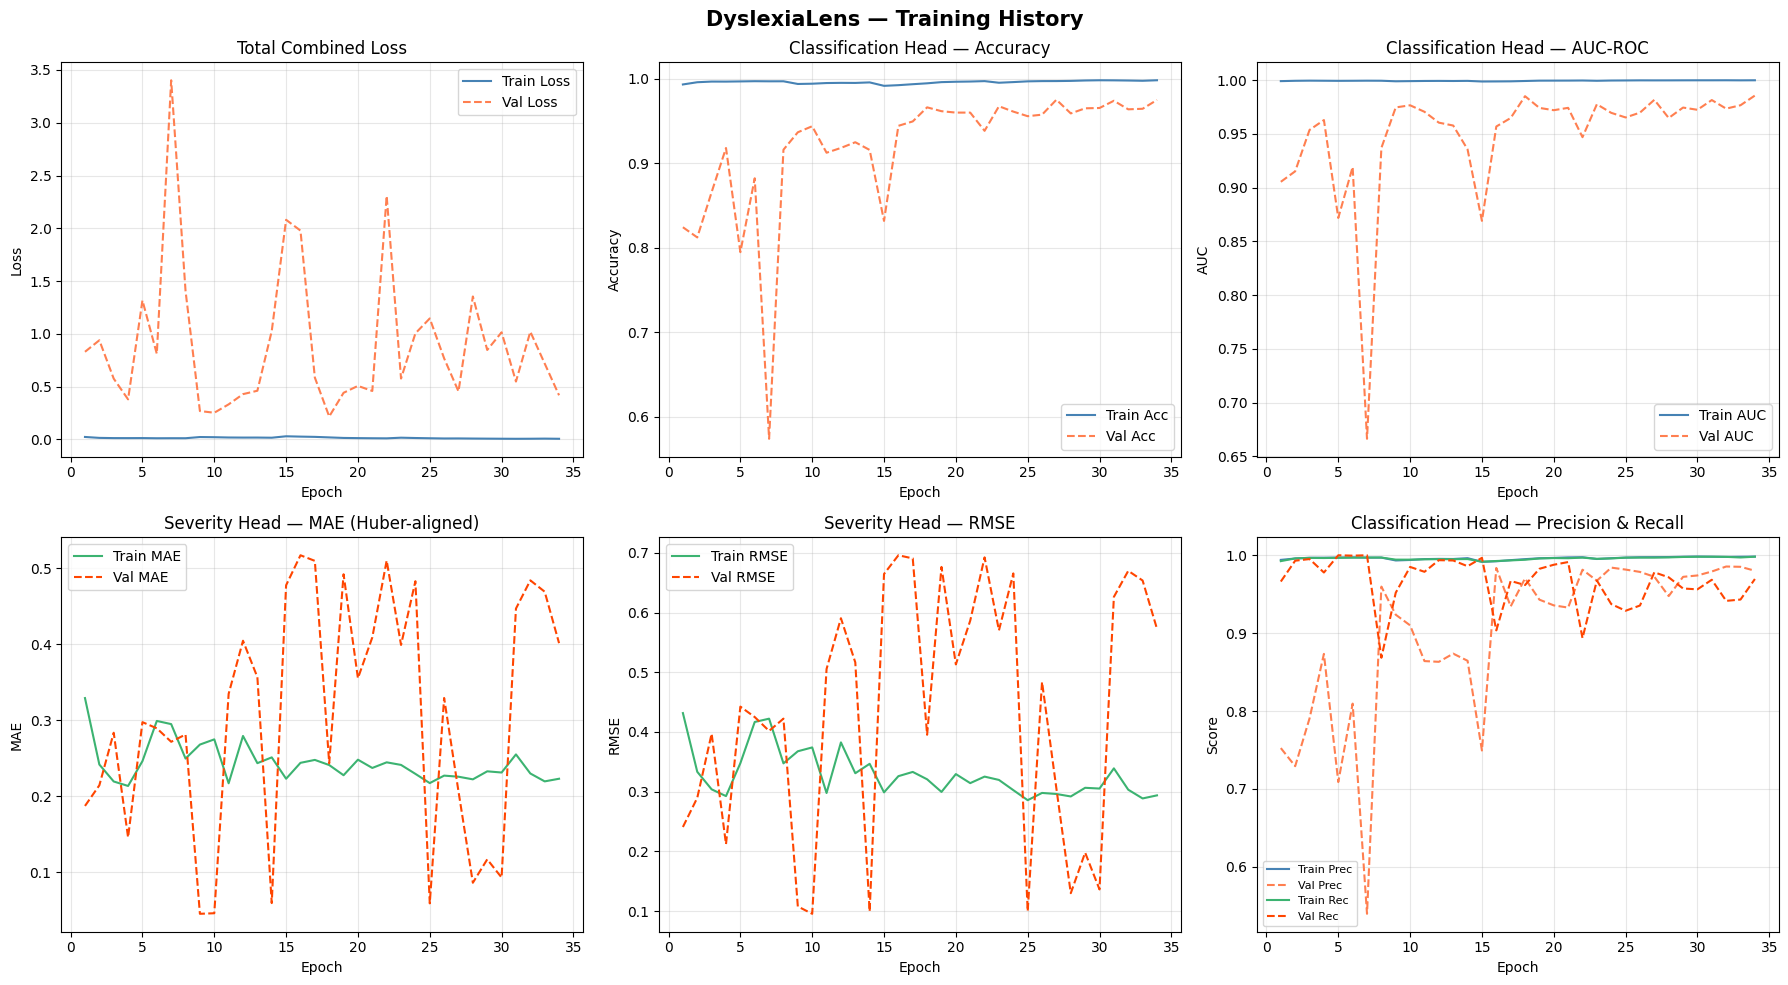

Saved → training_history.png


In [33]:
def plot_training_history(history):
    h = history.history
    epochs_ran = range(1, len(h['loss']) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('DyslexiaLens — Training History', fontsize=15, fontweight='bold')

    # 1. Total loss
    ax = axes[0, 0]
    ax.plot(epochs_ran, h['loss'],     label='Train Loss', color='steelblue')
    ax.plot(epochs_ran, h['val_loss'], label='Val Loss',   color='coral', linestyle='--')
    ax.set_title('Total Combined Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

    # 2. Classification accuracy
    ax = axes[0, 1]
    ax.plot(epochs_ran, h['classification_head_accuracy'],     label='Train Acc', color='steelblue')
    ax.plot(epochs_ran, h['val_classification_head_accuracy'], label='Val Acc',   color='coral', linestyle='--')
    ax.set_title('Classification Head — Accuracy')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(alpha=0.3)

    # 3. Classification AUC
    ax = axes[0, 2]
    ax.plot(epochs_ran, h['classification_head_auc'],     label='Train AUC', color='steelblue')
    ax.plot(epochs_ran, h['val_classification_head_auc'], label='Val AUC',   color='coral', linestyle='--')
    ax.set_title('Classification Head — AUC-ROC')
    ax.set_xlabel('Epoch'); ax.set_ylabel('AUC')
    ax.legend(); ax.grid(alpha=0.3)

    # 4. Severity MAE
    ax = axes[1, 0]
    ax.plot(epochs_ran, h['severity_head_mae'],     label='Train MAE', color='mediumseagreen')
    ax.plot(epochs_ran, h['val_severity_head_mae'], label='Val MAE',   color='orangered', linestyle='--')
    ax.set_title('Severity Head — MAE (Huber-aligned)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MAE')
    ax.legend(); ax.grid(alpha=0.3)

    # 5. Severity RMSE
    ax = axes[1, 1]
    ax.plot(epochs_ran, h['severity_head_rmse'],     label='Train RMSE', color='mediumseagreen')
    ax.plot(epochs_ran, h['val_severity_head_rmse'], label='Val RMSE',   color='orangered', linestyle='--')
    ax.set_title('Severity Head — RMSE')
    ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE')
    ax.legend(); ax.grid(alpha=0.3)

    # 6. Precision / Recall
    ax = axes[1, 2]
    ax.plot(epochs_ran, h['classification_head_precision'],     label='Train Prec', color='steelblue')
    ax.plot(epochs_ran, h['val_classification_head_precision'], label='Val Prec',   color='coral', linestyle='--')
    ax.plot(epochs_ran, h['classification_head_recall'],        label='Train Rec',  color='mediumseagreen')
    ax.plot(epochs_ran, h['val_classification_head_recall'],    label='Val Rec',    color='orangered', linestyle='--')
    ax.set_title('Classification Head — Precision & Recall')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → training_history.png")

plot_training_history(history)


## 13. Post-Training Threshold Sweep (Classification Head)

In [34]:
# ── 13.1  Collect raw probabilities from validation set ──────────────────────
# NOTE: val_ds yields 3-tuples (inputs, targets, sample_weight) because
# sample_weight is baked into the dataset. Inference only uses inputs + targets.

val_probs_cls = []
val_probs_sev = []
val_true_cls  = []
val_true_sev  = []

for inputs, targets, _ in val_ds:    # unpack 3 elements; discard sample_weight
    p_cls, p_sev = model(inputs, training=False)
    val_probs_cls.append(p_cls.numpy().flatten())
    val_probs_sev.append(p_sev.numpy().flatten())
    val_true_cls.append(targets['classification_head'].numpy().flatten())
    val_true_sev.append(targets['severity_head'].numpy().flatten())

val_probs_cls = np.concatenate(val_probs_cls)
val_probs_sev = np.concatenate(val_probs_sev)
val_true_cls  = np.concatenate(val_true_cls).astype(int)
val_true_sev  = np.concatenate(val_true_sev)

print(f"Validation samples collected: {len(val_probs_cls):,}")
print(f"  Classification prob range : [{val_probs_cls.min():.4f}, {val_probs_cls.max():.4f}]")
print(f"  Severity score range      : [{val_probs_sev.min():.4f}, {val_probs_sev.max():.4f}]")


Validation samples collected: 30,725
  Classification prob range : [0.0000, 1.0000]
  Severity score range      : [0.0006, 0.9875]


In [35]:
# ── 13.2  Sweep thresholds from 0.30 → 0.70 ─────────────────────────────────
sweep_results = []
for t in THRESHOLD_SWEEP_RANGE:
    preds = (val_probs_cls >= t).astype(int)
    acc   = np.mean(preds == val_true_cls)
    tp    = np.sum((preds == 1) & (val_true_cls == 1))
    fp    = np.sum((preds == 1) & (val_true_cls == 0))
    fn    = np.sum((preds == 0) & (val_true_cls == 1))
    prec  = tp / (tp + fp + 1e-8)
    rec   = tp / (tp + fn + 1e-8)
    f1    = 2 * prec * rec / (prec + rec + 1e-8)
    sweep_results.append({'threshold': t, 'accuracy': acc, 'precision': prec,
                           'recall': rec, 'f1': f1})

sweep_df = pd.DataFrame(sweep_results)
best_row  = sweep_df.loc[sweep_df['accuracy'].idxmax()]
OPTIMAL_THRESHOLD = best_row['threshold']

print("Threshold Sweep Results:")
print(sweep_df.to_string(index=False, float_format='{:.4f}'.format))
print(f"\n  ► Optimal threshold (max accuracy): t = {OPTIMAL_THRESHOLD:.2f}")
print(f"    Accuracy @ optimal t              : {best_row['accuracy']:.4f}")
print(f"    F1 score @ optimal t              : {best_row['f1']:.4f}")
print(f"    Precision @ optimal t             : {best_row['precision']:.4f}")
print(f"    Recall @ optimal t                : {best_row['recall']:.4f}")
print(f"\n  [BASELINE] Proven t=0.40 → Acc=97.86%, MAE=0.0214")


Threshold Sweep Results:
 threshold  accuracy  precision  recall     f1
    0.3000    0.9752     0.9708  0.9798 0.9753
    0.3100    0.9751     0.9708  0.9797 0.9752
    0.3200    0.9751     0.9708  0.9797 0.9752
    0.3300    0.9751     0.9710  0.9795 0.9752
    0.3400    0.9751     0.9710  0.9795 0.9752
    0.3500    0.9751     0.9711  0.9793 0.9752
    0.3600    0.9750     0.9711  0.9792 0.9751
    0.3700    0.9751     0.9713  0.9792 0.9752
    0.3800    0.9750     0.9713  0.9790 0.9751
    0.3900    0.9750     0.9714  0.9789 0.9751
    0.4000    0.9751     0.9716  0.9789 0.9752
    0.4100    0.9751     0.9717  0.9786 0.9752
    0.4200    0.9750     0.9717  0.9786 0.9751
    0.4300    0.9751     0.9718  0.9786 0.9752
    0.4400    0.9752     0.9720  0.9786 0.9753
    0.4500    0.9751     0.9721  0.9783 0.9752
    0.4600    0.9752     0.9723  0.9783 0.9753
    0.4700    0.9753     0.9724  0.9783 0.9753
    0.4800    0.9752     0.9724  0.9782 0.9753
    0.4900    0.9752     0.9724  0.

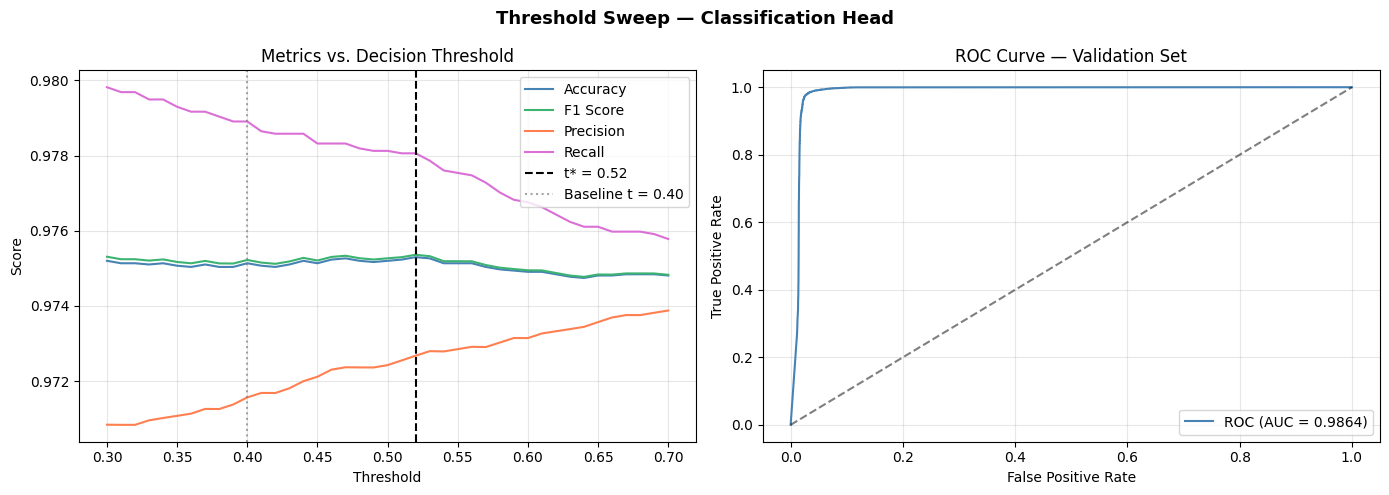

Saved → threshold_sweep.png


In [36]:
# ── 13.3  Visualise threshold sweep ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold Sweep — Classification Head', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(sweep_df['threshold'], sweep_df['accuracy'],  label='Accuracy',  color='steelblue')
ax.plot(sweep_df['threshold'], sweep_df['f1'],        label='F1 Score',  color='mediumseagreen')
ax.plot(sweep_df['threshold'], sweep_df['precision'], label='Precision', color='coral')
ax.plot(sweep_df['threshold'], sweep_df['recall'],    label='Recall',    color='orchid')
ax.axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--', label=f't* = {OPTIMAL_THRESHOLD:.2f}')
ax.axvline(DEFAULT_THRESHOLD, color='gray',  linestyle=':',  label=f'Baseline t = {DEFAULT_THRESHOLD:.2f}', alpha=0.7)
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Metrics vs. Decision Threshold')
ax.legend(); ax.grid(alpha=0.3)

# ROC Curve
fpr, tpr, _ = roc_curve(val_true_cls, val_probs_cls)
auc_score   = roc_auc_score(val_true_cls, val_probs_cls)
ax = axes[1]
ax.plot(fpr, tpr, color='steelblue', label=f'ROC (AUC = {auc_score:.4f})')
ax.plot([0,1],[0,1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Validation Set')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → threshold_sweep.png")


## 14. Final Evaluation on Test Set

In [37]:
# ── 14.1  Collect test predictions ───────────────────────────────────────────
# test_ds also yields 3-tuples (inputs, targets, sample_weight); discard sw.

test_probs_cls = []
test_probs_sev = []
test_true_cls  = []
test_true_sev  = []

for inputs, targets, _ in test_ds:    # unpack 3; discard sample_weight
    p_cls, p_sev = model(inputs, training=False)
    test_probs_cls.append(p_cls.numpy().flatten())
    test_probs_sev.append(p_sev.numpy().flatten())
    test_true_cls.append(targets['classification_head'].numpy().flatten())
    test_true_sev.append(targets['severity_head'].numpy().flatten())

test_probs_cls = np.concatenate(test_probs_cls)
test_probs_sev = np.concatenate(test_probs_sev)
test_true_cls  = np.concatenate(test_true_cls).astype(int)
test_true_sev  = np.concatenate(test_true_sev)

# Apply optimal threshold from sweep
test_preds_cls = (test_probs_cls >= OPTIMAL_THRESHOLD).astype(int)

# ── Classification metrics ────────────────────────────────────────────────────
test_acc  = np.mean(test_preds_cls == test_true_cls)
test_auc  = roc_auc_score(test_true_cls, test_probs_cls)

# ── Severity metrics ──────────────────────────────────────────────────────────
test_mae  = np.mean(np.abs(test_probs_sev - test_true_sev))
test_rmse = np.sqrt(np.mean((test_probs_sev - test_true_sev) ** 2))

print("=" * 60)
print("FINAL TEST SET RESULTS")
print("=" * 60)
print(f"  Classification Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  AUC-ROC                  : {test_auc:.4f}")
print(f"  Severity MAE             : {test_mae:.4f}")
print(f"  Severity RMSE            : {test_rmse:.4f}")
print(f"  Optimal threshold used   : t = {OPTIMAL_THRESHOLD:.2f}")
print("=" * 60)
print()
print("Baseline comparison:")
print(f"  Previous best (single-modal) @ t=0.40 : Acc=97.86%, MAE=0.0214")
print()
print(classification_report(
    test_true_cls, test_preds_cls,
    target_names=['Control (0)', 'Dyslexia (1)']
))


FINAL TEST SET RESULTS
  Classification Accuracy  : 0.9771  (97.71%)
  AUC-ROC                  : 0.9871
  Severity MAE             : 0.2070
  Severity RMSE            : 0.3060
  Optimal threshold used   : t = 0.52

Baseline comparison:
  Previous best (single-modal) @ t=0.40 : Acc=97.86%, MAE=0.0214

              precision    recall  f1-score   support

 Control (0)       0.98      0.97      0.98     15366
Dyslexia (1)       0.97      0.98      0.98     15359

    accuracy                           0.98     30725
   macro avg       0.98      0.98      0.98     30725
weighted avg       0.98      0.98      0.98     30725



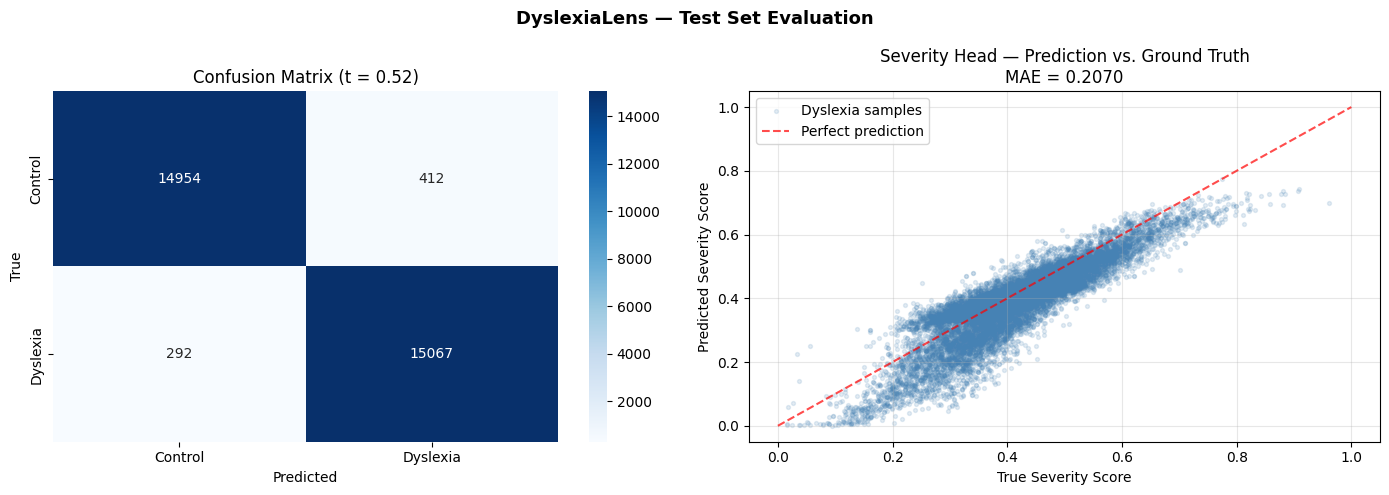

Saved → test_evaluation.png


In [38]:
# ── 14.2  Confusion matrix ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DyslexiaLens — Test Set Evaluation', fontsize=13, fontweight='bold')

cm = confusion_matrix(test_true_cls, test_preds_cls)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Control', 'Dyslexia'],
            yticklabels=['Control', 'Dyslexia'])
ax.set_title(f'Confusion Matrix (t = {OPTIMAL_THRESHOLD:.2f})')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

# Severity prediction scatter (Dyslexia samples only)
ax = axes[1]
mask_dys = test_true_cls == 1
ax.scatter(test_true_sev[mask_dys], test_probs_sev[mask_dys],
           alpha=0.15, s=8, color='steelblue', label='Dyslexia samples')
ax.plot([0, 1], [0, 1], 'r--', alpha=0.7, label='Perfect prediction')
ax.set_xlabel('True Severity Score')
ax.set_ylabel('Predicted Severity Score')
ax.set_title(f'Severity Head — Prediction vs. Ground Truth\nMAE = {test_mae:.4f}')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → test_evaluation.png")


## 15. Model Persistence

In [39]:
# All outputs go to /kaggle/working/ — visible in the Kaggle Output tab.
# Include logs/ directory in your repo submission for TensorBoard requirement.

model.save(MODEL_SAVE_PATH)
print(f"Full model saved  → {MODEL_SAVE_PATH}")

import pickle
with open(SCALER_SAVE_PATH, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Feature scaler    → {SCALER_SAVE_PATH}")

# Reload — must register BOTH custom objects: ACN layer + MaskedHuberLoss
reloaded = keras.models.load_model(
    MODEL_SAVE_PATH,
    custom_objects={
        'AdaptiveContrastNorm': AdaptiveContrastNorm,
        'MaskedHuberLoss':      MaskedHuberLoss,
    }
)
reloaded.summary(line_length=80)
print("\n✓ Model reloaded (ACN + MaskedHuberLoss both preserved via get_config).")

import subprocess
result = subprocess.run(['ls', '-lh', WORKING_DIR], capture_output=True, text=True)
print(f"\nFiles in {WORKING_DIR}:")
print(result.stdout)

# Remind user to download logs/ for TensorBoard requirement
print(f"\nTensorBoard logs → {LOG_DIR}")
print("Download /kaggle/working/logs/ from the Output tab and commit to your repo.")


Full model saved  → /kaggle/working/dyslexialens_model.keras
Feature scaler    → /kaggle/working/feature_scaler.pkl


Model: "DyslexiaLens_LateFusion"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ image_input           │ (None, 128, 128,  │           0 │ -                  │
│ (InputLayer)          │ 1)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ acn                   │ (None, 128, 128,  │           2 │ image_input[0][0]  │
│ (AdaptiveContrastNor… │ 1)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv1 (Conv2D)        │ (None, 128, 128,  │         320 │ acn[0][0]          │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bn1                   │ (None, 128, 128,  │         128 │ conv1[0][0]        │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ pool1 (MaxPooling2D)  │ (None, 64, 64,    │           0 │ bn1[0][0]          │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ drop1 (Dropout)       │ (None, 64, 64,    │           0 │ pool1[0][0]        │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2 (Conv2D)        │ (None, 64, 64,    │      18,496 │ drop1[0][0]        │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bn2                   │ (None, 64, 64,    │         256 │ conv2[0][0]        │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ pool2 (MaxPooling2D)  │ (None, 32, 32,    │           0 │ bn2[0][0]          │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ drop2 (Dropout)       │ (None, 32, 32,    │           0 │ pool2[0][0]        │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv3 (Conv2D)        │ (None, 32, 32,    │      73,856 │ drop2[0][0]        │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bn3                   │ (None, 32, 32,    │         512 │ conv3[0][0]        │
│ (BatchNormalization)  │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ pool3 (MaxPooling2D)  │ (None, 16, 16,    │           0 │ bn3[0][0]          │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ drop3 (Dropout)       │ (None, 16, 16,    │           0 │ pool3[0][0]        │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ feature_input         │ (None, 6)         │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv4 (Conv2D)        │ (None, 16, 16,    │     295,168 │ drop3[0][0]        │
│                       │ 256) 

 Total params: 1,522,670 (5.81 MB)

 Trainable params: 507,044 (1.93 MB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 1,014,090 (3.87 MB)


✓ Model reloaded (ACN + MaskedHuberLoss both preserved via get_config).

Files in /kaggle/working:
total 6.7M
drwxr-xr-x 2 root root 4.0K May 25 02:32 checkpoints
-rw-r--r-- 1 root root 6.0M May 25 03:16 dyslexialens_model.keras
-rw-r--r-- 1 root root  930 May 25 03:16 feature_scaler.pkl
drwxr-xr-x 4 root root 4.0K May 25 02:21 logs
-rw-r--r-- 1 root root 227K May 25 03:16 test_evaluation.png
-rw-r--r-- 1 root root 133K May 25 03:16 threshold_sweep.png
-rw-r--r-- 1 root root 367K May 25 03:15 training_history.png


TensorBoard logs → /kaggle/working/logs/20260525-022151
Download /kaggle/working/logs/ from the Output tab and commit to your repo.


## 16. Inference Utility Function

In [40]:
def predict_single_sample(
    image_path: str,
    raw_features: dict,
    model=model,
    scaler=scaler,
    threshold: float = OPTIMAL_THRESHOLD
) -> dict:
    """
    Run DyslexiaLens inference on a single handwriting image.

    Args:
        image_path   : Absolute or relative path to a .png image.
        raw_features : Dict with keys matching FEATURE_COLS (unscaled values).
        model        : Trained Keras model.
        scaler       : Fitted MinMaxScaler (from training).
        threshold    : Decision boundary for classification (default: optimal t).

    Returns:
        dict with:
            'dyslexia_probability' : float ∈ [0, 1]
            'predicted_class'      : 0 (Control) or 1 (Dyslexia)
            'label'                : 'Control' or 'Dyslexia'
            'severity_score'       : float ∈ [0, 1] (0 if Control)
            'severity_level'       : 'None' / 'Mild' / 'Moderate' / 'Severe'
    """
    # Load & preprocess image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=IMG_CHANNELS)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, 0)   # add batch dim

    # Scale features
    feat_vec = np.array([[raw_features[c] for c in FEATURE_COLS]], dtype=np.float32)
    feat_vec = scaler.transform(feat_vec)
    feat_vec = tf.constant(feat_vec, dtype=tf.float32)

    # Inference
    p_cls, p_sev = model({'image_input': img, 'feature_input': feat_vec}, training=False)
    prob_cls  = float(p_cls.numpy().flatten()[0])
    prob_sev  = float(p_sev.numpy().flatten()[0])

    predicted = int(prob_cls >= threshold)
    label     = 'Dyslexia' if predicted == 1 else 'Control'

    if predicted == 0:
        sev_level = 'None'
    elif prob_sev < 0.33:
        sev_level = 'Mild'
    elif prob_sev < 0.66:
        sev_level = 'Moderate'
    else:
        sev_level = 'Severe'

    return {
        'dyslexia_probability': round(prob_cls, 4),
        'predicted_class':      predicted,
        'label':                label,
        'severity_score':       round(prob_sev if predicted == 1 else 0.0, 4),
        'severity_level':       sev_level,
    }


print("predict_single_sample() ready for deployment integration.")
print()
print("Example call:")
print("""
result = predict_single_sample(
    image_path='path/to/sample.png',
    raw_features={
        'stroke_density':      0.15,
        'center_of_mass_x':    13.2,
        'center_of_mass_y':    13.5,
        'bounding_box_ratio':  1.05,
        'stroke_transitions':  2.14,
        'horizontal_symmetry': 0.83,
    }
)
print(result)
""")


predict_single_sample() ready for deployment integration.

Example call:

result = predict_single_sample(
    image_path='path/to/sample.png',
    raw_features={
        'stroke_density':      0.15,
        'center_of_mass_x':    13.2,
        'center_of_mass_y':    13.5,
        'bounding_box_ratio':  1.05,
        'stroke_transitions':  2.14,
        'horizontal_symmetry': 0.83,
    }
)
print(result)



## 17. Custom Training Loop — tf.GradientTape

Rubric requirement: implement a full custom training and evaluation loop from scratch using `tf.GradientTape`.

**Design decision:** We run this loop for 3 epochs on the **validation set as read-only evaluation** + a small **train subset** (5,000 samples) to demonstrate the full mechanics without disturbing the trained model weights. The trained model's final performance is already captured in §14; this section is a self-contained demonstration of the GradientTape API.


In [41]:
# ── 17.1  Custom training step ───────────────────────────────────────────────

# Instantiate fresh optimiser for the custom loop (separate from model.compile's)
tape_optimizer = keras.optimizers.Adam(learning_rate=1e-4)

# Loss functions (same as model.compile — reuse our custom MaskedHuberLoss)
clf_loss_fn = keras.losses.BinaryCrossentropy()
sev_loss_fn = MaskedHuberLoss(delta=0.5)

# Metrics — tracked manually, reset each epoch
train_clf_acc  = keras.metrics.BinaryAccuracy(name='train_clf_acc')
train_sev_mae  = keras.metrics.MeanAbsoluteError(name='train_sev_mae')
val_clf_acc    = keras.metrics.BinaryAccuracy(name='val_clf_acc')
val_sev_mae    = keras.metrics.MeanAbsoluteError(name='val_sev_mae')


@tf.function
def train_step(inputs, targets, sample_weight):
    """
    One forward + backward pass using tf.GradientTape.

    Steps:
      1. Record forward pass inside the tape context.
      2. Compute weighted multi-task loss.
      3. Compute gradients w.r.t. all trainable variables.
      4. Apply gradients via the optimiser.
      5. Update metrics.
    """
    with tf.GradientTape() as tape:
        # Forward pass (training=True enables Dropout + BatchNorm in train mode)
        p_cls, p_sev = model(inputs, training=True)

        y_cls = tf.cast(targets['classification_head'], tf.float32)
        y_sev = tf.cast(targets['severity_head'],       tf.float32)

        # Per-head losses
        loss_clf = clf_loss_fn(y_cls, p_cls, sample_weight=sample_weight)
        loss_sev = sev_loss_fn(y_sev, p_sev)

        # Weighted combination (matches model.compile loss_weights)
        total_loss = LOSS_WEIGHT_CLS * loss_clf + LOSS_WEIGHT_SEV * loss_sev

    # Compute gradients w.r.t. all trainable variables
    gradients = tape.gradient(total_loss, model.trainable_variables)

    # Clip gradients to prevent any potential explosion
    gradients, _ = tf.clip_by_global_norm(gradients, clip_norm=1.0)

    # Apply update
    tape_optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    # Update running metrics
    train_clf_acc.update_state(y_cls, p_cls)
    train_sev_mae.update_state(y_sev, p_sev)

    return total_loss


@tf.function
def eval_step(inputs, targets):
    """
    One forward pass for evaluation (no gradient recording, training=False).
    """
    p_cls, p_sev = model(inputs, training=False)
    y_cls = tf.cast(targets['classification_head'], tf.float32)
    y_sev = tf.cast(targets['severity_head'],       tf.float32)

    val_clf_acc.update_state(y_cls, p_cls)
    val_sev_mae.update_state(y_sev, p_sev)


print("train_step() and eval_step() compiled with @tf.function.")
print("Custom GradientTape loop ready.")


train_step() and eval_step() compiled with @tf.function.
Custom GradientTape loop ready.


In [42]:
# ── 17.2  Build a small subset dataset for the demo loop ─────────────────────
# Use 5,000 training samples and the full validation set.
# This keeps the demo fast without retraining the production model.

TAPE_EPOCHS      = 3
TAPE_TRAIN_SIZE  = 5000

# Slice the first TAPE_TRAIN_SIZE rows from the training split
tape_train_ds = make_dataset(
    df_train['local_path'].values[:TAPE_TRAIN_SIZE],
    X_feat_train[:TAPE_TRAIN_SIZE],
    y_cls_train[:TAPE_TRAIN_SIZE],
    y_sev_train[:TAPE_TRAIN_SIZE],
    sample_weights=sample_weights_train[:TAPE_TRAIN_SIZE],
    training=False,    # no shuffle/augment for reproducible demo
    batch_size=BATCH_SIZE
)

print(f"GradientTape demo config:")
print(f"  Train subset : {TAPE_TRAIN_SIZE:,} samples ({TAPE_TRAIN_SIZE // BATCH_SIZE} batches/epoch)")
print(f"  Val set      : {len(df_val):,} samples")
print(f"  Epochs       : {TAPE_EPOCHS}")
print(f"  Optimiser LR : 1e-4  (low — avoids disturbing trained weights)")


GradientTape demo config:
  Train subset : 5,000 samples (78 batches/epoch)
  Val set      : 30,725 samples
  Epochs       : 3
  Optimiser LR : 1e-4  (low — avoids disturbing trained weights)


In [43]:
# ── 17.3  Custom training loop ───────────────────────────────────────────────

print("=" * 65)
print("CUSTOM tf.GradientTape TRAINING LOOP")
print("=" * 65)

tape_history = {
    'epoch': [], 'train_loss': [],
    'train_clf_acc': [], 'train_sev_mae': [],
    'val_clf_acc':   [], 'val_sev_mae':   [],
}

for epoch in range(TAPE_EPOCHS):

    # ── Reset metrics at the start of each epoch ─────────────────────────────
    train_clf_acc.reset_state()
    train_sev_mae.reset_state()
    val_clf_acc.reset_state()
    val_sev_mae.reset_state()

    # ── Training phase ────────────────────────────────────────────────────────
    epoch_loss = []
    for step, (inputs, targets, sw) in enumerate(tape_train_ds):
        batch_loss = train_step(inputs, targets, sw)
        epoch_loss.append(float(batch_loss))

    mean_loss = np.mean(epoch_loss)

    # ── Evaluation phase ──────────────────────────────────────────────────────
    for inputs, targets, _ in val_ds:
        eval_step(inputs, targets)

    # ── Collect results ───────────────────────────────────────────────────────
    e_train_acc = float(train_clf_acc.result())
    e_train_mae = float(train_sev_mae.result())
    e_val_acc   = float(val_clf_acc.result())
    e_val_mae   = float(val_sev_mae.result())

    tape_history['epoch'].append(epoch + 1)
    tape_history['train_loss'].append(mean_loss)
    tape_history['train_clf_acc'].append(e_train_acc)
    tape_history['train_sev_mae'].append(e_train_mae)
    tape_history['val_clf_acc'].append(e_val_acc)
    tape_history['val_sev_mae'].append(e_val_mae)

    print(f"Epoch {epoch+1}/{TAPE_EPOCHS}  |  "
          f"loss: {mean_loss:.4f}  |  "
          f"train_acc: {e_train_acc:.4f}  train_mae: {e_train_mae:.4f}  |  "
          f"val_acc: {e_val_acc:.4f}  val_mae: {e_val_mae:.4f}")

print("\nCustom training loop complete.")
print(pd.DataFrame(tape_history).to_string(index=False))


CUSTOM tf.GradientTape TRAINING LOOP


E0000 00:00:1779679010.861330      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDyslexiaLens_LateFusion_1/drop1_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 1/3  |  loss: 0.0107  |  train_acc: 0.9964  train_mae: 0.0404  |  val_acc: 0.9498  val_mae: 0.0879
Epoch 2/3  |  loss: 0.0018  |  train_acc: 0.9998  train_mae: 0.0410  |  val_acc: 0.9227  val_mae: 0.0984
Epoch 3/3  |  loss: 0.0016  |  train_acc: 0.9998  train_mae: 0.0415  |  val_acc: 0.9228  val_mae: 0.0966

Custom training loop complete.
 epoch  train_loss  train_clf_acc  train_sev_mae  val_clf_acc  val_sev_mae
     1    0.010747         0.9964       0.040406     0.949780     0.087930
     2    0.001790         0.9998       0.041037     0.922701     0.098374
     3    0.001601         0.9998       0.041510     0.922832     0.096565
